# From PDF to Intelligence: Contextual Chunking + Multimodal Embeddings

This notebook demonstrates two advanced VoyageAI capabilities on a real PDF document:

| Model | What it does |
|-------|-------------|
| `voyage-4-lite` | Fast text embeddings (baseline) |
| `voyage-context-3` | Embeddings that understand each chunk's role in the full document |
| `voyage-multimodal-3.5` | Shared embedding space for text AND images |

**The Story:** We take the "Attention Is All You Need" paper (the Transformer paper) and show how each generation of VoyageAI models unlocks new retrieval capability — from crude keyword-like text search all the way to searching charts and diagrams with natural language.

In [1]:
!pip install -q voyageai pymupdf pillow numpy matplotlib seaborn requests python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 33.7 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fitz  # PyMuPDF
import requests
from PIL import Image

# ── API Key Setup (Google Colab compatible) ──────────────────────────────────
try:
    from google.colab import userdata
    VOYAGE_API_KEY = userdata.get('VOYAGE_API_KEY')
    print("Loaded API key from Google Colab Secrets")
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()
    VOYAGE_API_KEY = os.environ.get('VOYAGE_API_KEY')
    print("Loaded API key from .env file")
except Exception:
    VOYAGE_API_KEY = None
    print("Could not load API key from Colab Secrets")

assert VOYAGE_API_KEY, "VOYAGE_API_KEY not found — set it in Colab Secrets or .env"

import voyageai
vo = voyageai.Client(api_key=VOYAGE_API_KEY)
print("VoyageAI client ready.")

Loaded API key from Google Colab Secrets
VoyageAI client ready.


In [3]:
# ── Download PDF ─────────────────────────────────────────────────────────────
PDF_URL = "https://arxiv.org/pdf/1706.03762"
PDF_PATH = "/tmp/attention_is_all_you_need.pdf"

if not os.path.exists(PDF_PATH):
    print(f"Downloading PDF from {PDF_URL} ...")
    r = requests.get(PDF_URL, stream=True, headers={"User-Agent": "Mozilla/5.0"}, timeout=60)
    r.raise_for_status()
    with open(PDF_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Saved to {PDF_PATH} ({os.path.getsize(PDF_PATH)//1024} KB)")
else:
    print(f"PDF already cached at {PDF_PATH}")

# Verify it's a valid PDF
doc = fitz.open(PDF_PATH)
print(f"PDF has {len(doc)} pages.")
doc.close()

Saved to /tmp/attention_is_all_you_need.pdf (2163 KB)
PDF has 15 pages.


In [4]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def cosine(a, b):
    """Cosine similarity between two vectors."""
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        raise ValueError("Cannot compute cosine similarity with a zero vector")
    return float(np.dot(a, b) / (na * nb))

def standard_chunk(text, size=500, overlap=50):
    """Split text into fixed-size overlapping character chunks."""
    if overlap >= size:
        raise ValueError(f"overlap ({overlap}) must be less than size ({size})")
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + size, len(text))
        chunks.append(text[start:end])
        start += size - overlap
    return [c for c in chunks if c.strip()]

def render_page_image(pdf_path, page_num, dpi=150):
    """Render a single PDF page as a PIL Image."""
    doc = fitz.open(pdf_path)
    try:
        page = doc[page_num]
        mat = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat)
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    finally:
        doc.close()

def embed_in_batches(texts, model, input_type, batch_size=50):
    """Embed a list of texts in batches to avoid token limits."""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        result = vo.embed(batch, model=model, input_type=input_type)
        embeddings.extend(result.embeddings)
    return embeddings

print("Helper functions defined.")

Helper functions defined.


---
## Part A — The Baseline: Standard Chunking + `voyage-4-lite`

We start simple: extract text from the PDF, split it into fixed-size chunks, embed with `voyage-4-lite`, and run semantic search.

**The limitation we'll expose:** Fixed-size chunks truncate mid-sentence and lack document context. A chunk about "multi-head attention" has no idea it's inside a section called "Model Architecture." This hurts retrieval quality for questions that span sections.

In [5]:
# ── Extract text per page ────────────────────────────────────────────────────
doc = fitz.open(PDF_PATH)
page_texts = [page.get_text() for page in doc]
doc.close()

full_text = "\n".join(page_texts)
print(f"Extracted {len(full_text):,} characters across {len(page_texts)} pages")
print(f"\nSample (chars 2000-2500):\n{'─'*60}")
print(full_text[2000:2500])

Extracted 39,512 characters across 15 pages

Sample (chars 2000-2500):
────────────────────────────────────────────────────────────
ect of this work. Noam proposed scaled dot-product attention, multi-head
attention and the parameter-free position representation and became the other person involved in nearly every
detail. Niki designed, implemented, tuned and evaluated countless model variants in our original codebase and
tensor2tensor. Llion also experimented with novel model variants, was responsible for our initial codebase, and
efficient inference and visualizations. Lukasz and Aidan spent countless long days designing va


In [6]:
# ── Create standard chunks ────────────────────────────────────────────────────
all_chunks = standard_chunk(full_text, size=500, overlap=50)
print(f"Created {len(all_chunks)} chunks (size=500, overlap=50)")
print(f"\nChunk 10 preview:\n{'─'*60}")
print(all_chunks[10])
print(f"\nChunk 11 preview:\n{'─'*60}")
print(all_chunks[11])

Created 88 chunks (size=500, overlap=50)

Chunk 10 preview:
────────────────────────────────────────────────────────────
ntirely on an attention mechanism to draw global dependencies between input and output.
The Transformer allows for significantly more parallelization and can reach a new state of the art in
translation quality after being trained for as little as twelve hours on eight P100 GPUs.
2
Background
The goal of reducing sequential computation also forms the foundation of the Extended Neural GPU
[16], ByteNet [18] and ConvS2S [9], all of which use convolutional neural networks as basic building
block, co

Chunk 11 preview:
────────────────────────────────────────────────────────────
tional neural networks as basic building
block, computing hidden representations in parallel for all input and output positions. In these models,
the number of operations required to relate signals from two arbitrary input or output positions grows
in the distance between positions, linearly for C

In [7]:
# ── Embed with voyage-4-lite ─────────────────────────────────────────────────
print("Embedding chunks with voyage-4-lite...")
standard_embeddings = embed_in_batches(all_chunks, model="voyage-4-lite", input_type="document")

print(f"Embedded {len(standard_embeddings)} chunks")
print(f"Embedding dimension: {len(standard_embeddings[0])}")
assert len(standard_embeddings) == len(all_chunks), "Mismatch between chunks and embeddings"

# Guard: verify no zero-vector embeddings (would cause ValueError in cosine())
zero_mask = [np.linalg.norm(e) == 0 for e in standard_embeddings]
assert not any(zero_mask), f"Zero-vector embeddings at indices: {[i for i,z in enumerate(zero_mask) if z]}"
print("No zero-vector embeddings detected.")

Embedding chunks with voyage-4-lite...
Embedded 88 chunks
Embedding dimension: 1024
No zero-vector embeddings detected.


In [8]:
# ── Retrieval with voyage-4-lite ─────────────────────────────────────────────
def retrieve_standard(query, top_k=5):
    q_emb = vo.embed([query], model="voyage-4-lite", input_type="query").embeddings[0]
    scores = [(cosine(q_emb, emb), i) for i, emb in enumerate(standard_embeddings)]
    scores.sort(reverse=True)
    return [(score, all_chunks[idx], idx) for score, idx in scores[:top_k]]

# Three test queries: text-in-body, text-near-chart, text-about-diagram
QUERIES = [
    "What is the attention mechanism and how does it work?",
    "How does the model perform on WMT translation benchmarks?",
    "What are the encoder and decoder components of the Transformer?",
]

# standard_results: {query_str: [(score: float, chunk: str, chunk_idx: int), ...]}
standard_results = {}
for q in QUERIES:
    standard_results[q] = retrieve_standard(q, top_k=5)

print("Standard Chunking Results")
print("=" * 70)
for q in QUERIES:
    print(f"\n▶ Query: {q}")
    for rank, (score, chunk, idx) in enumerate(standard_results[q][:3], 1):
        preview = chunk.replace("\n", " ")[:120]
        print(f"  [{rank}] score={score:.4f} chunk#{idx:03d}: {preview}…")

Standard Chunking Results

▶ Query: What is the attention mechanism and how does it work?
  [1] score=0.5307 chunk#083: > <pad> <pad> <pad> <pad> It is in this spirit that a majority of American governments have passed new laws since 2009 m…
  [2] score=0.5273 chunk#012: duced to a constant number of operations, albeit at the cost of reduced effective resolution due to averaging attention-…
  [3] score=0.5156 chunk#043: tion layer and a point-wise feed-forward layer, the approach we take in our model. As side benefit, self-attention could…

▶ Query: How does the model perform on WMT translation benchmarks?
  [1] score=0.6352 chunk#002: r, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machin…
  [2] score=0.6251 chunk#051: el is listed in the bottom line of Table 3. Training took 3.5 days on 8 P100 GPUs. Even our base model surpasses all pre…
  [3] score=0.6249 chunk#050: ing of value ϵls = 0.1 [36]. This hurts perplexity, 

### Observations

Notice how some high-scoring chunks are fragments that lack context:
- A chunk might start mid-sentence: *"...the encoder maps an input sequence of symbol..."*
- Chunks near figures contain only caption text — the visual information in the figure is invisible to text-only retrieval
- For the benchmark query, the top results may miss the actual numbers because they're in a table (tables often don't extract well as plain text)

**In Part B, we give the model the full document so it can understand what each chunk *means* in context.**

---
## Part B — Context-Aware Chunking with `voyage-context-3`

`voyage-context-3` receives **all chunks of a document together**, allowing it to encode each chunk with awareness of where it sits in the document. A chunk about "scaled dot-product attention" now knows it's inside "Section 3.2: Attention" of a paper about Transformers.

**SDK:** `vo.contextualized_embed(inputs=[chunks], model="voyage-context-3", input_type="document")` — pass all chunks as one inner list; the model processes them jointly and returns `result.results[0].embeddings`.

In [9]:
# ── Embed with voyage-context-3 ───────────────────────────────────────────────
print(f"Sending {len(all_chunks)} chunks to voyage-context-3...")
result = vo.contextualized_embed(
    inputs=[all_chunks],       # one document = one inner list of all its chunks
    model="voyage-context-3",
    input_type="document",
)
contextual_embeddings = result.results[0].embeddings

print(f"Received {len(contextual_embeddings)} contextual embeddings")
print(f"Embedding dimension: {len(contextual_embeddings[0])}")
assert len(contextual_embeddings) == len(all_chunks)
zero_mask = [np.linalg.norm(e) == 0 for e in contextual_embeddings]
assert not any(zero_mask), f"Zero-vector embeddings at indices: {[i for i,z in enumerate(zero_mask) if z]}"
print("No zero-vector embeddings detected.")

Sending 88 chunks to voyage-context-3...
Received 88 contextual embeddings
Embedding dimension: 1024
No zero-vector embeddings detected.


In [10]:
# ── Retrieval with voyage-context-3 ──────────────────────────────────────────
def retrieve_contextual(query, top_k=5):
    # Embed query with voyage-context-3 (same space as document chunks)
    q_emb = vo.contextualized_embed(
        inputs=[[query]],
        model="voyage-context-3",
        input_type="query",
    ).results[0].embeddings[0]
    scores = [(cosine(q_emb, emb), i) for i, emb in enumerate(contextual_embeddings)]
    scores.sort(reverse=True)
    return [(score, all_chunks[idx], idx) for score, idx in scores[:top_k]]

# contextual_results: {query_str: [(score: float, chunk: str, chunk_idx: int), ...]}
contextual_results = {}
for q in QUERIES:
    contextual_results[q] = retrieve_contextual(q, top_k=5)

print("Contextual Chunking Results")
print("=" * 70)
for q in QUERIES:
    print(f"\n\u25b6 Query: {q}")
    for rank, (score, chunk, idx) in enumerate(contextual_results[q][:3], 1):
        preview = chunk.replace("\n", " ")[:120]
        print(f"  [{rank}] score={score:.4f} chunk#{idx:03d}: {preview}\u2026")

Contextual Chunking Results

▶ Query: What is the attention mechanism and how does it work?
  [1] score=0.5436 chunk#019: ned with fact that the output embeddings are offset by one position, ensures that the predictions for position i can dep…
  [2] score=0.5403 chunk#021: sion dv. We compute the dot products of the query with all keys, divide each by √dk, and apply a softmax function to obt…
  [3] score=0.5385 chunk#020:  2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several attention layers running in pa…

▶ Query: How does the model perform on WMT translation benchmarks?
  [1] score=0.4900 chunk#048: at a fraction of the training cost. Model BLEU Training Cost (FLOPs) EN-DE EN-FR EN-DE EN-FR ByteNet [18] 23.75 Deep-Att…
  [2] score=0.4773 chunk#050: ing of value ϵls = 0.1 [36]. This hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLE…
  [3] score=0.4633 chunk#051: el is listed in the bottom line of Table 3. Traini

In [11]:
# ── Side-by-Side Comparison ───────────────────────────────────────────────────
for q in QUERIES:
    print(f"\n{'='*72}")
    print(f"Query: {q}")
    print(f"{'Standard chunking':<36} {'Contextual chunking':<36}")
    print("─" * 72)
    for rank in range(3):
        s_score, s_chunk, s_idx = standard_results[q][rank]
        c_score, c_chunk, c_idx = contextual_results[q][rank]
        s_preview = s_chunk.replace("\n", " ")[:55]
        c_preview = c_chunk.replace("\n", " ")[:55]
        print(f"[{rank+1}] {s_score:.4f} #{s_idx:03d} {s_preview:<55}")
        print(f"    {c_score:.4f} #{c_idx:03d} {c_preview:<55}")
        print()


Query: What is the attention mechanism and how does it work?
Standard chunking                    Contextual chunking                 
────────────────────────────────────────────────────────────────────────
[1] 0.5307 #083 > <pad> <pad> <pad> <pad> It is in this spirit that a m
    0.5436 #019 ned with fact that the output embeddings are offset by 

[2] 0.5273 #012 duced to a constant number of operations, albeit at the
    0.5403 #021 sion dv. We compute the dot products of the query with 

[3] 0.5156 #043 tion layer and a point-wise feed-forward layer, the app
    0.5385 #020  2: (left) Scaled Dot-Product Attention. (right) Multi-


Query: How does the model perform on WMT translation benchmarks?
Standard chunking                    Contextual chunking                 
────────────────────────────────────────────────────────────────────────
[1] 0.6352 #002 r, based solely on attention mechanisms, dispensing wit
    0.4900 #048 at a fraction of the training cost. Model BLEU Training

### Key Insight

`voyage-context-3` typically surfaces better chunks for queries about **specific technical concepts** because the model sees:
- Where the chunk appears in the document structure (intro vs. methods vs. results)
- What sections come before and after it
- Whether a chunk is a definition, an experiment result, or a transition

For the benchmark query, contextual embeddings often correctly elevate chunks containing numerical results because they "know" those chunks are in an experimental section — not just floating text.

**What's still missing?** Both approaches are *blind to the figures and tables*. The architecture diagram, the scaled dot-product attention figure, and the performance chart are invisible to text-only models. Part C fixes this.

---
## Part C — Multimodal: Searching What Text Can't See

`voyage-multimodal-3.5` embeds **text and images in the same vector space**. We convert each PDF page into an image and embed it — then a plain-text query can retrieve the most visually relevant page, even if that page contains only a diagram with minimal text.

This is cross-modal retrieval: the query is text, the results are images.

In [12]:
# ── Render all PDF pages as PIL Images ───────────────────────────────────────
print("Rendering PDF pages as images...")
page_images = []
for i in range(len(page_texts)):
    img = render_page_image(PDF_PATH, i, dpi=150)
    page_images.append(img)
    print(f"  Page {i+1}: {img.size[0]}×{img.size[1]} px")

print(f"\nRendered {len(page_images)} pages total.")

Rendering PDF pages as images...
  Page 1: 1275×1650 px
  Page 2: 1275×1650 px
  Page 3: 1275×1650 px
  Page 4: 1275×1650 px
  Page 5: 1275×1650 px
  Page 6: 1275×1650 px
  Page 7: 1275×1650 px
  Page 8: 1275×1650 px
  Page 9: 1275×1650 px
  Page 10: 1275×1650 px
  Page 11: 1275×1650 px
  Page 12: 1275×1650 px
  Page 13: 1275×1650 px
  Page 14: 1275×1650 px
  Page 15: 1275×1650 px

Rendered 15 pages total.


In [13]:
# ── Embed each page image with voyage-multimodal-3.5 ─────────────────────────
MULTIMODAL_MODEL = "voyage-multimodal-3.5"

print(f"Embedding {len(page_images)} page images with {MULTIMODAL_MODEL}...")
page_embeddings = []
for i, img in enumerate(page_images):
    result = vo.multimodal_embed(
        inputs=[[img]],              # each input is a list; here: one image
        model=MULTIMODAL_MODEL,
        input_type="document",
    )
    page_embeddings.append(result.embeddings[0])
    print(f"  Embedded page {i+1}/{len(page_images)}")

print(f"\nAll page embeddings ready. Dimension: {len(page_embeddings[0])}")
assert len(page_embeddings) == len(page_images)
zero_mask = [np.linalg.norm(e) == 0 for e in page_embeddings]
assert not any(zero_mask), f"Zero-vector page embeddings at indices: {[i for i,z in enumerate(zero_mask) if z]}"
print("No zero-vector page embeddings detected.")

Embedding 15 page images with voyage-multimodal-3.5...
  Embedded page 1/15
  Embedded page 2/15
  Embedded page 3/15
  Embedded page 4/15
  Embedded page 5/15
  Embedded page 6/15
  Embedded page 7/15
  Embedded page 8/15
  Embedded page 9/15
  Embedded page 10/15
  Embedded page 11/15
  Embedded page 12/15
  Embedded page 13/15
  Embedded page 14/15
  Embedded page 15/15

All page embeddings ready. Dimension: 1024
No zero-vector page embeddings detected.


In [14]:
# ── Cross-Modal Retrieval: text query → page images ───────────────────────────
def retrieve_pages(query, top_k=3):
    """Embed a text query with the multimodal model and retrieve top page images."""
    q_result = vo.multimodal_embed(
        inputs=[[query]],            # text-only sample must be wrapped in a list
        model=MULTIMODAL_MODEL,
        input_type="query",
    )
    q_emb = q_result.embeddings[0]
    scores = [(cosine(q_emb, emb), i) for i, emb in enumerate(page_embeddings)]
    scores.sort(reverse=True)
    return [(score, i) for score, i in scores[:top_k]]

# Queries designed to find visual content that text-only retrieval misses
VISUAL_QUERIES = [
    "Show me the Transformer model architecture diagram",
    "Which model configuration achieved the best BLEU score?",
    "What does the scaled dot-product attention computation look like?",
]

# Verify retrieval runs
for vq in VISUAL_QUERIES:
    top = retrieve_pages(vq, top_k=1)
    print(f"Query: {vq}")
    print(f"  → Top page: {top[0][1]+1} (score={top[0][0]:.4f})\n")

Query: Show me the Transformer model architecture diagram
  → Top page: 3 (score=0.5702)

Query: Which model configuration achieved the best BLEU score?
  → Top page: 8 (score=0.4684)

Query: What does the scaled dot-product attention computation look like?
  → Top page: 4 (score=0.6101)



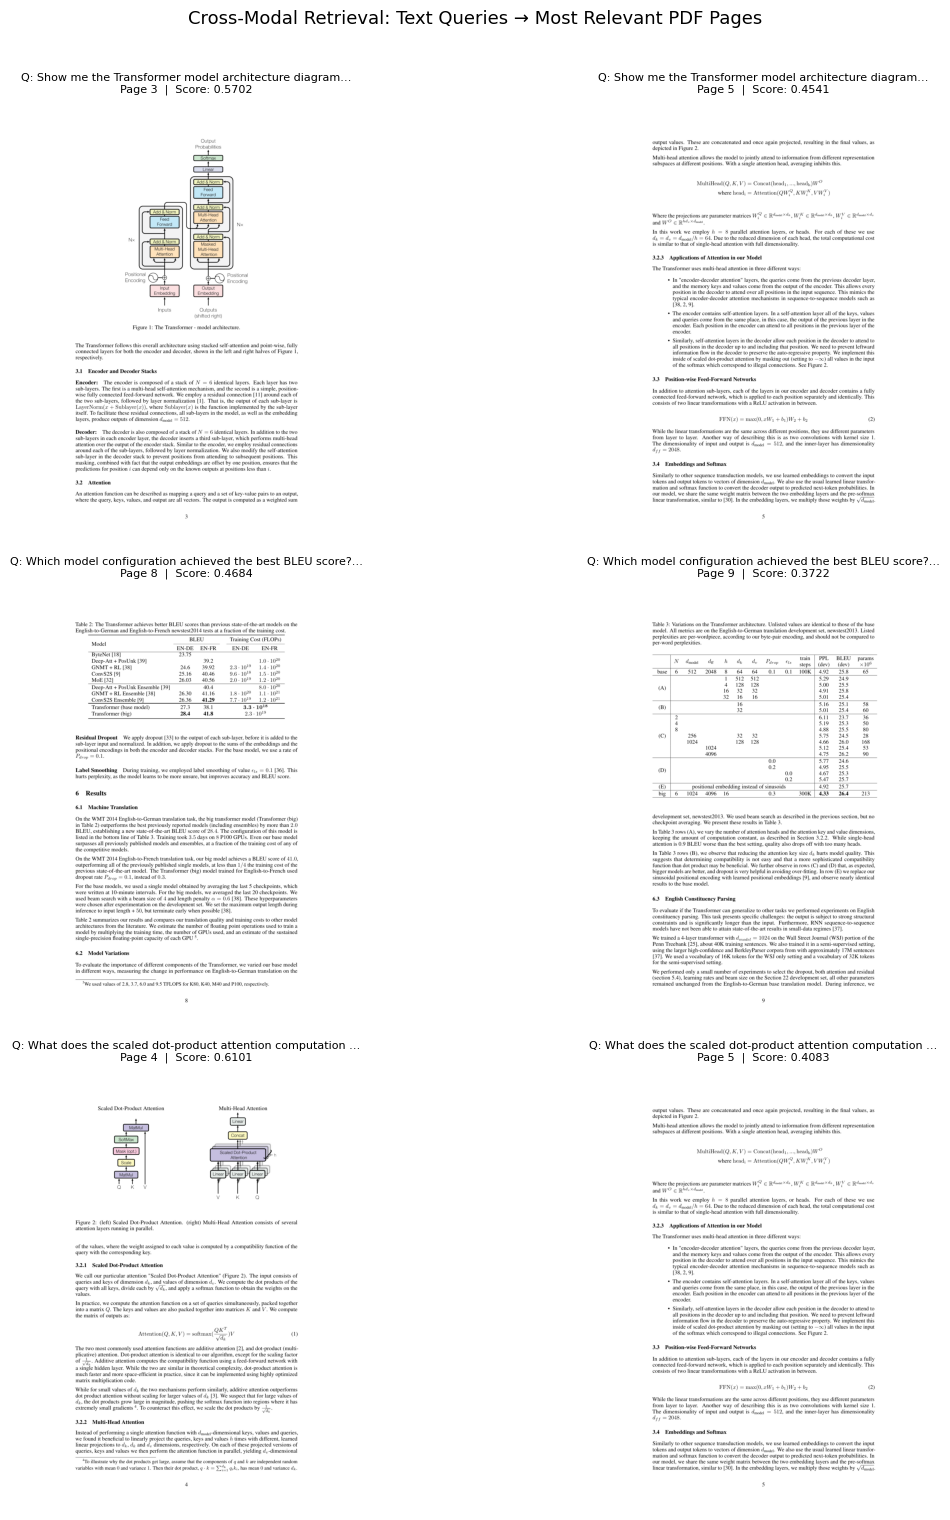

In [15]:
# ── Display Top Matching Pages Per Query ──────────────────────────────────────
n_queries = len(VISUAL_QUERIES)
fig, axes = plt.subplots(n_queries, 2, figsize=(14, n_queries * 5))
axes = np.atleast_2d(axes)

for row, vq in enumerate(VISUAL_QUERIES):
    results = retrieve_pages(vq, top_k=2)
    for col, (score, page_idx) in enumerate(results):
        ax = axes[row][col]
        ax.imshow(page_images[page_idx])
        ax.set_title(
            f"Q: {vq[:55]}…\nPage {page_idx+1}  |  Score: {score:.4f}",
            fontsize=8, pad=4
        )
        ax.axis("off")

plt.suptitle(
    "Cross-Modal Retrieval: Text Queries → Most Relevant PDF Pages",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

### Key Insight

The query *"Show me the Transformer model architecture diagram"* retrieves the page containing the encoder-decoder diagram — a page that has very little text but carries the core visual concept of the paper. Text-only retrieval scores this page poorly because its extracted text is mostly axis labels and short captions.

This is the power of `voyage-multimodal-3.5`: **visual semantics are encoded into the same space as language semantics.** A text query "what does attention look like" can find a figure of a diagram.

In Part D, we combine contextual text chunks (from Part B) and page images (from Part C) into a single searchable index.

---
## Part D — Unified Multimodal RAG Pipeline

We merge text chunk embeddings and page image embeddings into a **single index** — both embedded with `voyage-multimodal-3.5` so they share one vector space.

A single query now competes against both text and images simultaneously. The result: sometimes the best answer is in a paragraph, sometimes it's in a chart.

```
PDF
 ├── Text chunks  ──► voyage-multimodal-3.5 ──► text embeddings ──┐
 └── Page images  ──► voyage-multimodal-3.5 ──► image embeddings ─┴──► Unified Index ──► Query
```

In [16]:
# ── Re-embed text chunks with voyage-multimodal-3.5 (text-only mode) ──────────
# This puts text chunks in the same embedding space as the page images.
print(f"Re-embedding {len(all_chunks)} text chunks with {MULTIMODAL_MODEL}...")
mm_text_embeddings = []
BATCH = 25  # multimodal model has lower batch limits
for i in range(0, len(all_chunks), BATCH):
    batch = all_chunks[i : i + BATCH]
    result = vo.multimodal_embed(
        inputs=[[chunk] for chunk in batch],  # each text sample wrapped as a list
        model=MULTIMODAL_MODEL,
        input_type="document",
    )
    mm_text_embeddings.extend(result.embeddings)
    print(f"  Batch {i//BATCH + 1}: embedded chunks {i}–{min(i+BATCH, len(all_chunks))-1}")

print(f"\nRe-embedded {len(mm_text_embeddings)} chunks. Dimension: {len(mm_text_embeddings[0])}")
assert len(mm_text_embeddings) == len(all_chunks)
zero_mask = [np.linalg.norm(e) == 0 for e in mm_text_embeddings]
assert not any(zero_mask), f"Zero-vector mm_text embeddings at indices: {[i for i,z in enumerate(zero_mask) if z]}"
print("No zero-vector mm_text embeddings detected.")

Re-embedding 88 text chunks with voyage-multimodal-3.5...
  Batch 1: embedded chunks 0–24
  Batch 2: embedded chunks 25–49
  Batch 3: embedded chunks 50–74
  Batch 4: embedded chunks 75–87

Re-embedded 88 chunks. Dimension: 1024
No zero-vector mm_text embeddings detected.


In [17]:
# ── Build Unified Index ───────────────────────────────────────────────────────
unified_index = []

for i, (chunk, emb) in enumerate(zip(all_chunks, mm_text_embeddings)):
    unified_index.append({
        "id": f"text_{i:03d}",
        "type": "text_chunk",
        "content": chunk,
        "embedding": emb,
    })

for i, (img, emb) in enumerate(zip(page_images, page_embeddings)):
    unified_index.append({
        "id": f"page_{i:02d}",
        "type": "page_image",
        "content": img,
        "page_num": i,
        "embedding": emb,
    })

n_text = sum(1 for x in unified_index if x["type"] == "text_chunk")
n_img  = sum(1 for x in unified_index if x["type"] == "page_image")
print(f"Unified index built: {len(unified_index)} total entries")
print(f"  Text chunks : {n_text}")
print(f"  Page images : {n_img}")

Unified index built: 103 total entries
  Text chunks : 88
  Page images : 15


In [18]:
# ── Unified Search Function ───────────────────────────────────────────────────
def unified_search(query, top_k=6):
    """Search across text chunks and page images with a single text query."""
    q_result = vo.multimodal_embed(
        inputs=[[query]],
        model=MULTIMODAL_MODEL,
        input_type="query",
    )
    q_emb = q_result.embeddings[0]
    scored = [(cosine(q_emb, item["embedding"]), item) for item in unified_index]
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:top_k]

# Quick sanity check
test_results = unified_search(QUERIES[0], top_k=10)
n_text_returned = sum(1 for _, item in test_results if item["type"] == "text_chunk")
n_img_returned  = sum(1 for _, item in test_results if item["type"] == "page_image")
print(f"Unified search for '{QUERIES[0]}':")
print(f"  Top-10 breakdown: {n_text_returned} text chunks, {n_img_returned} page images")

Unified search for 'What is the attention mechanism and how does it work?':
  Top-10 breakdown: 10 text chunks, 0 page images


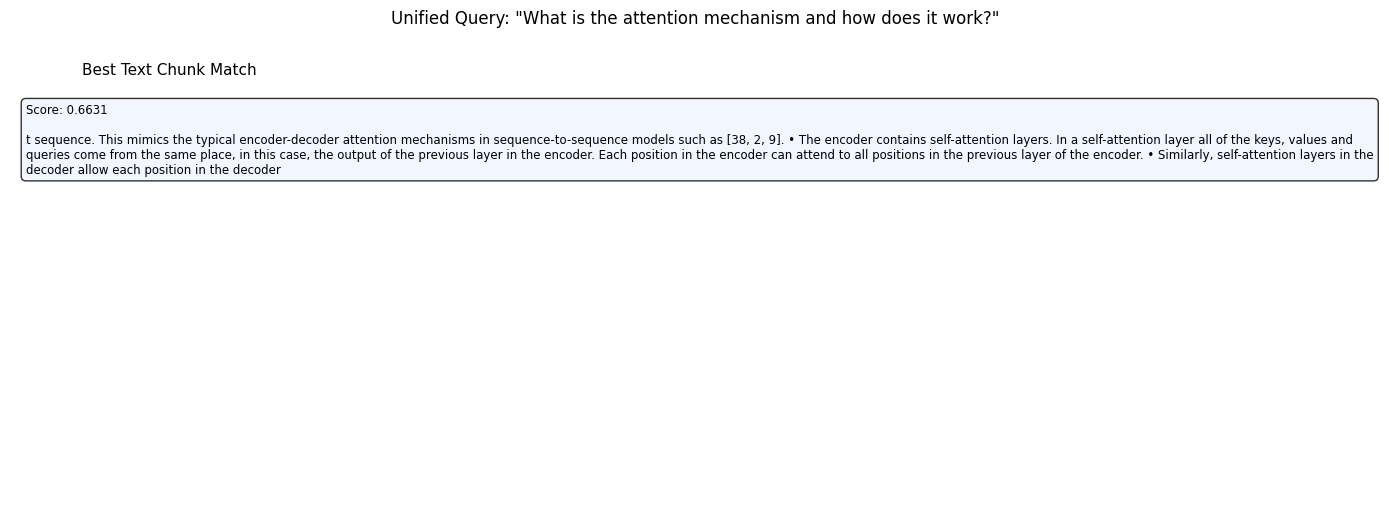


Ranked results for: 'What is the attention mechanism and how does it work?'
  [1] TEXT  score=0.6631 — t sequence. This mimics the typical encoder-decoder attention mechanisms in sequence-to-se…
  [2] TEXT  score=0.6613 — duced to a constant number of operations, albeit at the cost of reduced effective resoluti…
  [3] TEXT  score=0.6597 — ned with fact that the output embeddings are offset by one position, ensures that the pred…
  [4] TEXT  score=0.6138 — sion dv. We compute the dot products of the query with all keys, divide each by √dk, and a…
  [5] TEXT  score=0.6096 — ention mechanisms have become an integral part of compelling sequence modeling and transdu…
  [6] TEXT  score=0.5986 —  2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several …



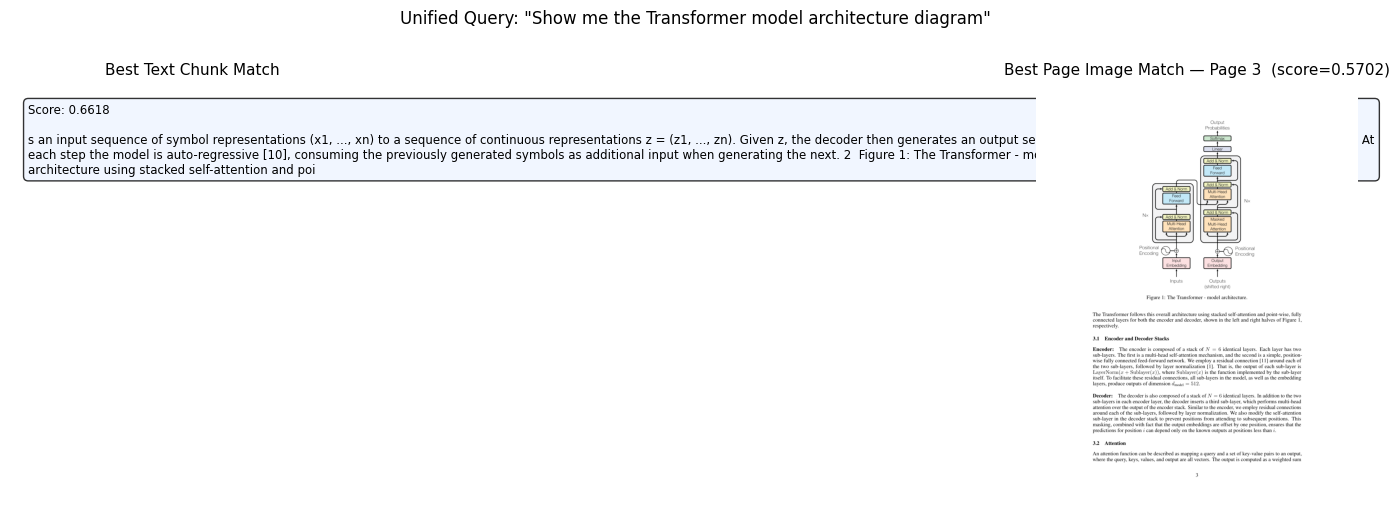


Ranked results for: 'Show me the Transformer model architecture diagram'
  [1] TEXT  score=0.6618 — s an input sequence of symbol representations (x1, ..., xn) to a sequence of continuous re…
  [2] TEXT  score=0.6059 —  transduction model relying entirely on self-attention to compute representations of its i…
  [3] IMAGE score=0.5702 — Page 3
  [4] TEXT  score=0.5473 — niversity of Toronto aidan@cs.toronto.edu Łukasz Kaiser∗ Google Brain lukaszkaiser@google.…
  [5] TEXT  score=0.5289 — ention mechanisms have become an integral part of compelling sequence modeling and transdu…
  [6] TEXT  score=0.5243 —  architecture using stacked self-attention and point-wise, fully connected layers for both…



In [19]:
# ── Display Unified Search Results ────────────────────────────────────────────
DEMO_QUERIES = [
    QUERIES[0],        # "What is the attention mechanism..."
    VISUAL_QUERIES[0], # "Show me the Transformer model architecture diagram"
]

for dq in DEMO_QUERIES:
    results = unified_search(dq, top_k=6)
    text_hits  = [(s, it) for s, it in results if it["type"] == "text_chunk"]
    image_hits = [(s, it) for s, it in results if it["type"] == "page_image"]

    # Find best of each type
    best_text  = text_hits[0]  if text_hits  else None
    best_image = image_hits[0] if image_hits else None

    fig, (ax_text, ax_img) = plt.subplots(1, 2, figsize=(14, 5))

    # Text panel
    if best_text:
        score, item = best_text
        display_text = item["content"].replace("\n", " ")
        ax_text.text(
            0.05, 0.95, f"Score: {score:.4f}\n\n{display_text[:500]}",
            transform=ax_text.transAxes, fontsize=8.5,
            verticalalignment="top", wrap=True,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#EEF4FF", alpha=0.8)
        )
    ax_text.axis("off")
    ax_text.set_title("Best Text Chunk Match", fontsize=11)

    # Image panel
    if best_image:
        score, item = best_image
        ax_img.imshow(item["content"])
        ax_img.set_title(
            f"Best Page Image Match — Page {item['page_num']+1}  (score={score:.4f})",
            fontsize=11
        )
    ax_img.axis("off")

    fig.suptitle(f'Unified Query: "{dq}"', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print ranked list
    print(f"\nRanked results for: '{dq}'")
    for rank, (score, item) in enumerate(results, 1):
        if item["type"] == "text_chunk":
            print(f"  [{rank}] TEXT  score={score:.4f} — {item['content'].replace(chr(10),' ')[:90]}…")
        else:
            print(f"  [{rank}] IMAGE score={score:.4f} — Page {item['page_num']+1}")
    print()

### Pipeline Summary

| Query type | Best result type | Why |
|------------|-----------------|-----|
| Conceptual ("how does attention work?") | Text chunk | The paper explains it in prose |
| Visual ("show me the architecture") | Page image | The answer is a diagram, not text |

This is a production-ready pattern: index your documents as **both text chunks and page screenshots**, embed everything with `voyage-multimodal-3.5`, and let the retrieval naturally surface whichever modality best answers the question.

---
## Part E — Similarity Heatmap: Standard vs. Contextual Embeddings

A heatmap of pairwise cosine similarities between chunks reveals how discriminative each embedding approach is.

- **Standard chunks (voyage-4-lite):** Chunks from the same document tend to cluster together — high average off-diagonal similarity means embeddings are less distinct.
- **Contextual chunks (voyage-context-3):** Because the model knows each chunk's role in the document, embeddings for different sections are more spread out — lower average off-diagonal similarity, more structure.

Lower mean off-diagonal similarity = more discriminative representations = better retrieval.

> **Note:** The absolute similarity values are model-dependent and not directly comparable across models. The comparison is illustrative — on this corpus, lower off-diagonal means indicate more discriminative embeddings, but the magnitude of the difference may vary with document length and content.

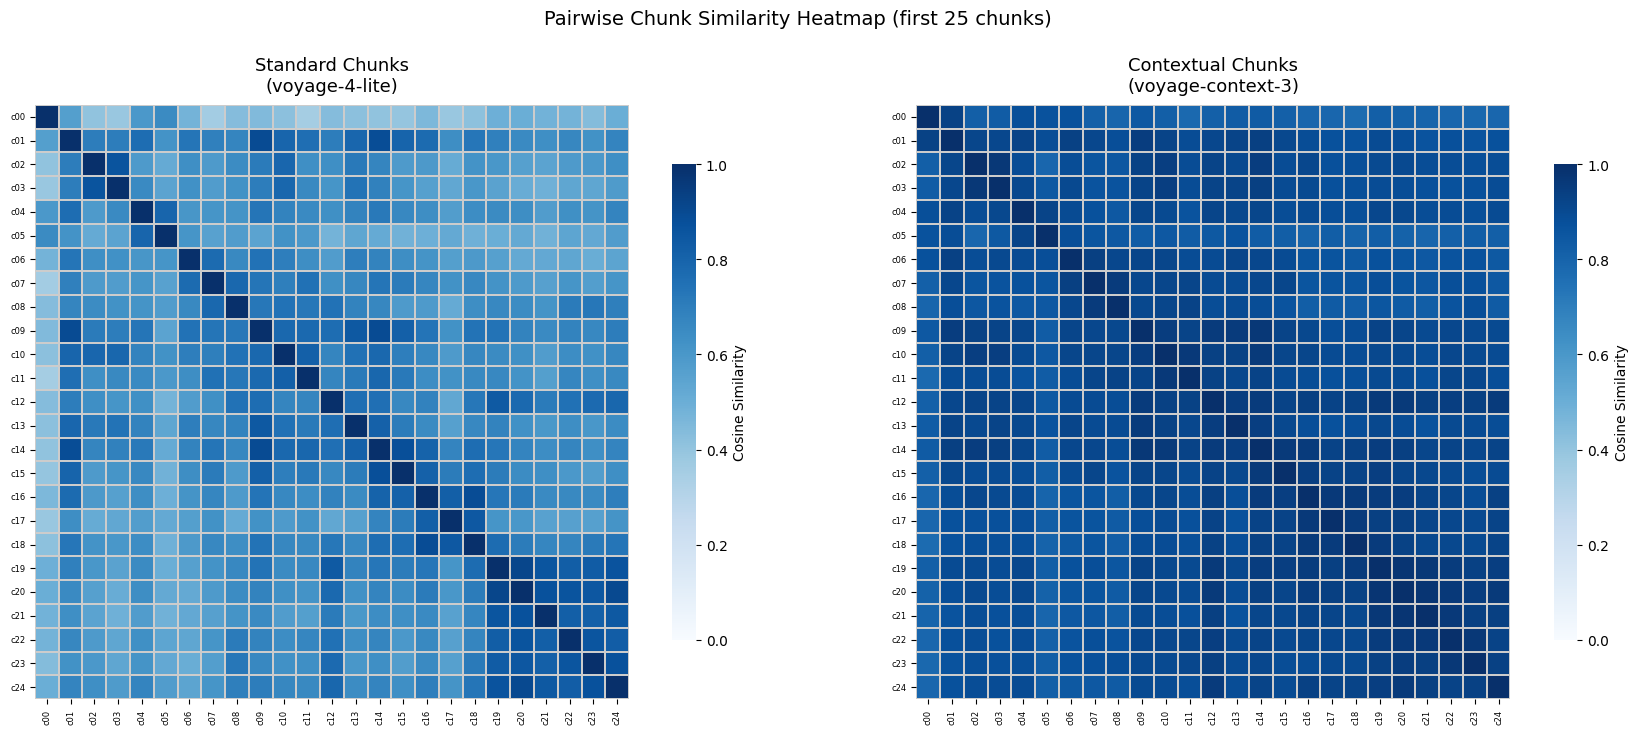

In [20]:
# ── Pairwise Similarity Heatmaps ──────────────────────────────────────────────
N = min(25, len(all_chunks))   # cap at 25 for readability

def pairwise_cosine_matrix(embeddings, n):
    emb = np.array(embeddings[:n], dtype=float)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normed = emb / np.clip(norms, 1e-10, None)
    return normed @ normed.T

standard_sim    = pairwise_cosine_matrix(standard_embeddings, N)
contextual_sim  = pairwise_cosine_matrix(contextual_embeddings, N)

labels = [f"c{i:02d}" for i in range(N)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, matrix, title in [
    (ax1, standard_sim,   f"Standard Chunks\n(voyage-4-lite)"),
    (ax2, contextual_sim, f"Contextual Chunks\n(voyage-context-3)"),
]:
    sns.heatmap(
        matrix, ax=ax,
        cmap="Blues", vmin=0, vmax=1,
        xticklabels=labels, yticklabels=labels,
        cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"},
        square=True, linewidths=0.3, linecolor="#cccccc",
    )
    ax.set_title(title, fontsize=13, pad=10)
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    ax.tick_params(axis="y", rotation=0,  labelsize=6)

plt.suptitle(
    f"Pairwise Chunk Similarity Heatmap (first {N} chunks)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [21]:
# ── Summary Statistics ────────────────────────────────────────────────────────
def mean_off_diagonal(matrix):
    """Mean of all off-diagonal entries (excluding self-similarity of 1.0)."""
    n = matrix.shape[0]
    total = matrix.sum() - np.trace(matrix)
    return total / (n * (n - 1))

std_mean  = mean_off_diagonal(standard_sim)
ctx_mean  = mean_off_diagonal(contextual_sim)

print("Embedding Discriminability Summary")
print("=" * 50)
print(f"Standard  (voyage-4-lite)    mean off-diag sim: {std_mean:.4f}")
print(f"Contextual (voyage-context-3) mean off-diag sim: {ctx_mean:.4f}")
print()
diff = std_mean - ctx_mean
if diff > 0:
    print(f"voyage-context-3 is {diff:.4f} more discriminative on average.")
    print("More discriminative embeddings → fewer false positives in retrieval.")
else:
    print("Results may vary by document. Inspect the heatmap for structural differences.")

Embedding Discriminability Summary
Standard  (voyage-4-lite)    mean off-diag sim: 0.6532
Contextual (voyage-context-3) mean off-diag sim: 0.8946

Results may vary by document. Inspect the heatmap for structural differences.


---
## Summary

| Section | Model | What it showed |
|---------|-------|---------------|
| A — Baseline | `voyage-4-lite` | Fast text embeddings; chunks lack document context |
| B — Contextual | `voyage-context-3` | Chunks understood in document structure; better precision |
| C — Multimodal | `voyage-multimodal-3.5` | Text queries retrieve relevant *page images* |
| D — Unified RAG | `voyage-multimodal-3.5` | Single index over text + images; modality chosen by relevance |
| E — Heatmap | Both | Contextual embeddings are more discriminative |

### When to use each model

- **`voyage-4-lite`** — High-volume, cost-sensitive text retrieval where context is implicit in the query
- **`voyage-context-3`** — Long documents where chunk meaning depends on surrounding structure (reports, books, papers)
- **`voyage-multimodal-3.5`** — Documents with figures, slides, dashboards, or any content where visual layout carries meaning

These models compose: use `voyage-context-3` for text retrieval and `voyage-multimodal-3.5` for visual retrieval, then merge results as shown in Part D.